In [157]:
# %% 라이브러리 및 데이터 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 1. Seaborn 스타일을 '먼저' 적용합니다.
sns.set_style('whitegrid')

# 2. 한글 폰트를 '나중에' 설정합니다. (SimHei -> Malgun Gothic 으로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

project_root = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
OUTPUT_DIR = project_root / 'data' / 'output'

# CSV 로드
rfm = pd.read_csv(OUTPUT_DIR / '상권별_RFM기초.csv')
자치구별_기초 = pd.read_csv(OUTPUT_DIR / '자치구별_기초집계.csv')
상권유형별_기초 = pd.read_csv(OUTPUT_DIR / '상권유형별_기초집계.csv')

print(f'RFM 데이터: {rfm.shape}')
print(f'주요 컬럼: {[c for c in rfm.columns if "R_" in c or "F_" in c or "M_" in c]}')
rfm.head()

RFM 데이터: (1575, 17)
주요 컬럼: ['R_매출증감률', 'F_결제건수', 'M_객단가']


,상권_코드,매출_2024,결제건수_2024,매출_2025,결제건수_2025,평균_유동인구,상권_코드_명,자치구_코드_명,상권_구분_코드_명,엑스좌표_값,와이좌표_값,R_매출증감률,결제건수_증감률,F_결제건수,M_객단가,결제전환율,진짜성장_플래그
0,3110238,2844923,71,932345235,1421,109625.000,배꽃어린이공원,중랑구,골목상권,206668,456017,326.722485,19.014085,746.0,656119.095707,0.006805,True
1,3130305,100244621,4506,2228266257,93458,29802.375,논현종합시장,강남구,전통시장,203038,445603,21.228288,19.740790,48982.0,23842.434644,1.643560,True
2,3130046,4476390498,225453,59128312308,2029651,66316.625,team204(팀204),중구,전통시장,201168,452028,12.208926,8.002546,1127552.0,29132.255894,17.002554,True
3,3110773,164716594,55,1843989966,434784,87162.375,당산역 13번,영등포구,골목상권,191087,448516,10.194925,7904.163636,217419.5,4241.163350,2.494419,True
4,3110563,44875963,474,358632127,6644,174187.625,상수역 3번,마포구,골목상권,193303,449582,6.991631,13.016878,3559.0,53978.345424,0.020432,True


In [158]:
# %% 전월세 데이터 로드 및 상권별 집계
import os

RENT_DIR = project_root / 'data' / 'extracted' / '서울시_전월세가'

df_list = []
for f in sorted(RENT_DIR.glob('*.csv')):
    try:
        df = pd.read_csv(f, encoding='utf-8')
    except:
        try:
            df = pd.read_csv(f, encoding='cp949')
        except:
            df = pd.read_csv(f, encoding='utf-8-sig')
    df_list.append(df)

df_전월세_원본 = pd.concat(df_list, ignore_index=True)
print(f'전월세 데이터 로드: {df_전월세_원본.shape}')
print(f'컬럼: {df_전월세_원본.columns.tolist()}')

# 월세 데이터만 필터 (전월세 아님)
df_월세 = df_전월세_원본[df_전월세_원본['전월세구분'] == '월세'].copy()

# 자치구별 월세 중앙값
df_월세_집계 = (
    df_월세[df_월세['접수년도'] == 2025]  # 최신 연도
    .rename(columns={'자치구명': '자치구_코드_명'})
    .groupby('자치구_코드_명')
    .agg({
        '임대료(만원)': 'median',
        '보증금(만원)': 'median',
        '임대면적': 'median'
    })
    .reset_index()
    .rename(columns={
        '임대료(만원)': '월세_임대료_중앙값',
        '보증금(만원)': '월세_보증금_중앙값',
        '임대면적': '평균_면적'
    })
)

print(f'\\n자치구별 월세 정보 (2025년):')
print(df_월세_집계)

전월세 데이터 로드: (3238096, 23)
컬럼: ['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번', '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도', '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료']
\n자치구별 월세 정보 (2025년):
   자치구_코드_명  월세_임대료_중앙값  월세_보증금_중앙값   평균_면적
0       강남구        90.0      9073.0  41.910
1       강동구        48.0      5000.0  36.000
2       강북구        50.0      1000.0  33.000
3       강서구        54.0      3000.0  28.450
4       관악구        50.0      2000.0  22.380
5       광진구        55.0      2000.0  28.865
6       구로구        46.0      2566.0  35.000
7       금천구        50.0      2000.0  28.000
8       노원구        52.0      2000.0  41.300
9       도봉구        50.0      2000.0  39.750
10     동대문구        57.0      2000.0  26.650
11      동작구        50.0      2500.0  25.740
12      마포구        66.0      3000.0  30.000
13     서대문구        58.0      1000.0  27.190
14      서초구        83.0     10000.0  49.330
15      성동구        66.0      5000.0  36.000
16    

In [159]:
# %% RFM 점수 산출 (5분위수)
# ── 결측값 확인 ──
print('결측값 현황:')
print(rfm[['R_매출증감률', 'F_결제건수', 'M_객단가']].isnull().sum())

# ── NaN 제거 ──
rfm_clean = rfm[rfm[['R_매출증감률', 'F_결제건수', 'M_객단가']].notna().all(axis=1)].copy()
print(f'\n분석 대상 상권: {len(rfm_clean)}개 / 전체 {len(rfm)}개')

# ── 5분위수 점수 부여 ──
rfm_clean['R_점수'] = pd.qcut(rfm_clean['R_매출증감률'], q=5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm_clean['F_점수'] = pd.qcut(rfm_clean['F_결제건수'],    q=5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm_clean['M_점수'] = pd.qcut(rfm_clean['M_객단가'],      q=5, labels=[1,2,3,4,5], duplicates='drop').astype(int)

# ── RFM 통합 점수 ──
rfm_clean['RFM_합계'] = rfm_clean['R_점수'] + rfm_clean['F_점수'] + rfm_clean['M_점수']

# ── 점수 분포 ──
print('\n점수 분포:')
print(f'R 점수 (성장): {rfm_clean["R_점수"].value_counts().sort_index().to_dict()}')
print(f'F 점수 (빈도): {rfm_clean["F_점수"].value_counts().sort_index().to_dict()}')
print(f'M 점수 (금액): {rfm_clean["M_점수"].value_counts().sort_index().to_dict()}')
print(f'\nRFM 합계 분포:\n{rfm_clean["RFM_합계"].value_counts().sort_index()}')

결측값 현황:
R_매출증감률    0
F_결제건수     0
M_객단가      0
dtype: int64

분석 대상 상권: 1575개 / 전체 1575개

점수 분포:
R 점수 (성장): {1: 315, 2: 315, 3: 315, 4: 315, 5: 315}
F 점수 (빈도): {1: 315, 2: 315, 3: 315, 4: 315, 5: 315}
M 점수 (금액): {1: 315, 2: 315, 3: 315, 4: 315, 5: 315}

RFM 합계 분포:
RFM_합계
3       6
4      36
5      65
6     128
7     206
8     201
9     243
10    252
11    234
12     99
13     74
14     26
15      5
Name: count, dtype: int64


In [160]:
# %% 상권별 타겟층 정보 통합 (연령대, 성별)

# ── sales 데이터 로드 (2025년 파일만, 연령대·성별 컬럼 필요) ──
SALES_DIR = project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)'
sales_2025 = pd.read_csv(
    SALES_DIR / '서울시_상권분석서비스(추정매출-상권)_2025년.csv',
    encoding='cp949', low_memory=False
)
print(f'2025년 매출 데이터 로드: {sales_2025.shape}')

# ── 상권별 연령대 정보 ──
연령_컬럼_dict = {
    '연령대_10_매출_금액': '10대',
    '연령대_20_매출_금액': '20대',
    '연령대_30_매출_금액': '30대',
    '연령대_40_매출_금액': '40대',
    '연령대_50_매출_금액': '50대',
    '연령대_60_이상_매출_금액': '60대이상'
}

rfm_연령 = (
    sales_2025
    .groupby('상권_코드')[list(연령_컬럼_dict.keys())].sum()
    .reset_index()
)

# 연령대별 비중 계산
연령_컬럼_list = list(연령_컬럼_dict.keys())
rfm_연령['총매출'] = rfm_연령[연령_컬럼_list].sum(axis=1)

for col in 연령_컬럼_list:
    새컬럼명 = 연령_컬럼_dict[col] + '_비중'
    rfm_연령[새컬럼명] = rfm_연령[col] / rfm_연령['총매출'].replace(0, np.nan)

# 주력 연령대
비중_컬럼 = [f'{v}_비중' for v in 연령_컬럼_dict.values()]
rfm_연령['주력_연령대'] = rfm_연령[비중_컬럼].idxmax(axis=1).str.replace('_비중', '')
rfm_연령 = rfm_연령[['상권_코드', '주력_연령대'] + 비중_컬럼]

# ── 상권별 성별 정보 ──
rfm_성별 = (
    sales_2025
    .groupby('상권_코드')[['남성_매출_금액', '여성_매출_금액']].sum()
    .reset_index()
)

rfm_성별['총매출'] = rfm_성별['남성_매출_금액'] + rfm_성별['여성_매출_금액']
rfm_성별['남성_비중'] = rfm_성별['남성_매출_금액'] / rfm_성별['총매출'].replace(0, np.nan)
rfm_성별['여성_비중'] = rfm_성별['여성_매출_금액'] / rfm_성별['총매출'].replace(0, np.nan)
rfm_성별['주력_성별'] = rfm_성별.apply(lambda x: '남성' if x['남성_비중'] > 0.5 else '여성', axis=1)
rfm_성별 = rfm_성별[['상권_코드', '주력_성별', '남성_비중', '여성_비중']]

# ── RFM에 통합 (rfm_clean은 이미 자치구_코드_명 보유) ──
rfm_clean = (
    rfm_clean
    .merge(rfm_연령, on='상권_코드', how='left')
    .merge(rfm_성별, on='상권_코드', how='left')
    .merge(df_월세_집계, on='자치구_코드_명', how='left')
)

print('✅ 타겟층 및 월세정보 통합 완료')
print(f'추가 컬럼: 주력_연령대, 남성_비중, 여성_비중, 월세_임대료_중앙값, 월세_보증금_중앙값')
print(rfm_clean[['상권_코드_명', '주력_연령대', '주력_성별', '남성_비중', '월세_임대료_중앙값']].head())

2025년 매출 데이터 로드: (85732, 55)
✅ 타겟층 및 월세정보 통합 완료
추가 컬럼: 주력_연령대, 남성_비중, 여성_비중, 월세_임대료_중앙값, 월세_보증금_중앙값
         상권_코드_명 주력_연령대 주력_성별     남성_비중  월세_임대료_중앙값
0        배꽃어린이공원  60대이상    남성  0.674768        45.0
1         논현종합시장    50대    여성  0.328581        90.0
2  team204(팀204)    30대    여성  0.268967        73.0
3        당산역 13번    30대    남성  0.631838        53.0
4         상수역 3번    50대    남성  0.726073        66.0


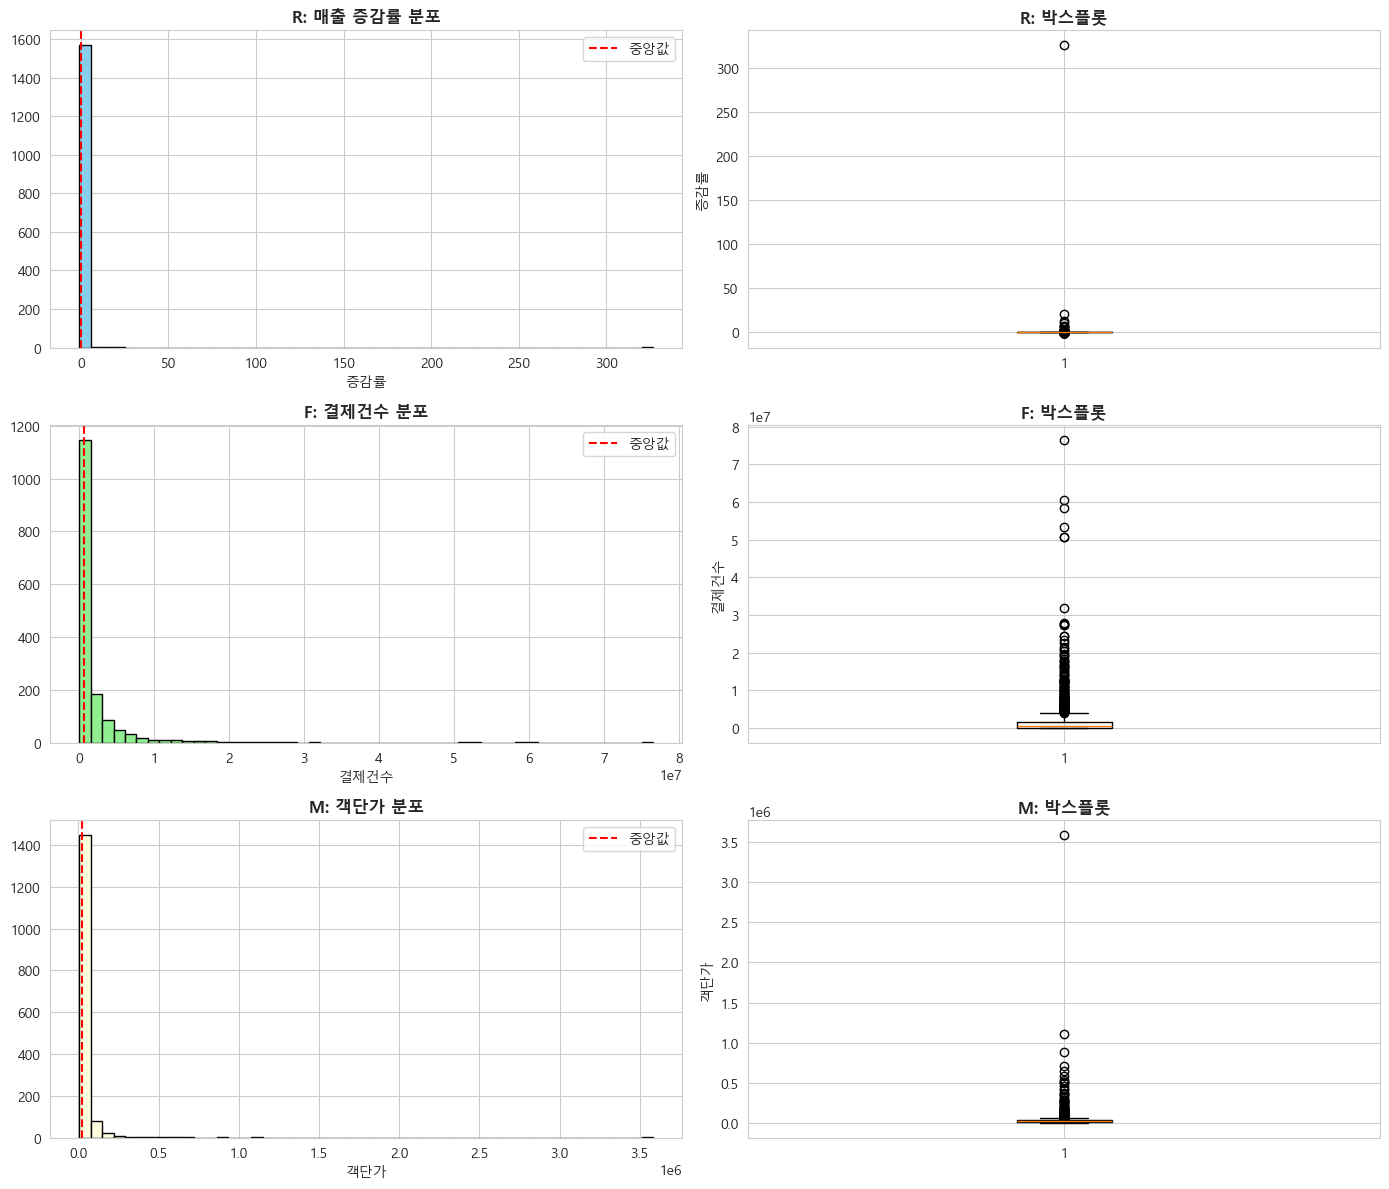

✅ RFM 분포 분석 완료


In [161]:
# %% RFM 분포 분석 (히스토그램 & 박스플롯)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# R: 매출 증감률
axes[0, 0].hist(rfm_clean['R_매출증감률'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('R: 매출 증감률 분포', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('증감률')
axes[0, 0].axvline(rfm_clean['R_매출증감률'].median(), color='red', linestyle='--', label='중앙값')
axes[0, 0].legend()

axes[0, 1].boxplot(rfm_clean['R_매출증감률'], vert=True)
axes[0, 1].set_title('R: 박스플롯', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('증감률')

# F: 결제건수
axes[1, 0].hist(rfm_clean['F_결제건수'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('F: 결제건수 분포', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('결제건수')
axes[1, 0].axvline(rfm_clean['F_결제건수'].median(), color='red', linestyle='--', label='중앙값')
axes[1, 0].legend()

axes[1, 1].boxplot(rfm_clean['F_결제건수'], vert=True)
axes[1, 1].set_title('F: 박스플롯', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('결제건수')

# M: 객단가
axes[2, 0].hist(rfm_clean['M_객단가'], bins=50, color='lightyellow', edgecolor='black')
axes[2, 0].set_title('M: 객단가 분포', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('객단가')
axes[2, 0].axvline(rfm_clean['M_객단가'].median(), color='red', linestyle='--', label='중앙값')
axes[2, 0].legend()

axes[2, 1].boxplot(rfm_clean['M_객단가'], vert=True)
axes[2, 1].set_title('M: 박스플롯', fontsize=12, fontweight='bold')
axes[2, 1].set_ylabel('객단가')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'RFM_분포분석.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ RFM 분포 분석 완료')

In [162]:
# %% 극단치 탐지 (IQR 방법)
def find_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  범위: [{lower:.2f}, {upper:.2f}]')
    print(f'  극단치: {len(outliers)}개 ({len(outliers)/len(series)*100:.1f}%)')
    return outliers

print('=== 극단치 탐지 (IQR 방법) ===\n')
r_outliers = find_outliers(rfm_clean['R_매출증감률'], 'R: 매출증감률')
print()
f_outliers = find_outliers(rfm_clean['F_결제건수'], 'F: 결제건수')
print()
m_outliers = find_outliers(rfm_clean['M_객단가'], 'M: 객단가')

=== 극단치 탐지 (IQR 방법) ===

R: 매출증감률:
  Q1=-0.09, Q3=0.05, IQR=0.14
  범위: [-0.29, 0.26]
  극단치: 186개 (11.8%)

F: 결제건수:
  Q1=149306.25, Q3=1740543.75, IQR=1591237.50
  범위: [-2237550.00, 4127400.00]
  극단치: 183개 (11.6%)

M: 객단가:
  Q1=18681.24, Q3=37469.84, IQR=18788.60
  범위: [-9501.66, 65652.75]
  극단치: 165개 (10.5%)


In [163]:
# %% 인플레이션 필터링 검증
# 진짜성장(매출↑ AND 결제건수↑) vs 가짜성장(매출↑ AND 결제건수↓)
rfm_clean['성장유형'] = '기타'
rfm_clean.loc[(rfm_clean['R_매출증감률'] > 0) & (rfm_clean['결제건수_증감률'] > 0), '성장유형'] = '진짜성장'
rfm_clean.loc[(rfm_clean['R_매출증감률'] > 0) & (rfm_clean['결제건수_증감률'] <= 0), '성장유형'] = '가짜성장(인플레이션)'
rfm_clean.loc[(rfm_clean['R_매출증감률'] <= 0) & (rfm_clean['결제건수_증감률'] > 0), '성장유형'] = '저가성장'
rfm_clean.loc[(rfm_clean['R_매출증감률'] <= 0) & (rfm_clean['결제건수_증감률'] <= 0), '성장유형'] = '침체'

print('=== 성장유형 분류 ===\n')
성장분류 = rfm_clean['성장유형'].value_counts()
print(성장분류)
print(f'\n비율: {(성장분류 / len(rfm_clean) * 100).round(1).to_dict()}')

=== 성장유형 분류 ===

성장유형
침체             821
진짜성장           373
가짜성장(인플레이션)    274
저가성장           107
Name: count, dtype: int64

비율: {'침체': 52.1, '진짜성장': 23.7, '가짜성장(인플레이션)': 17.4, '저가성장': 6.8}


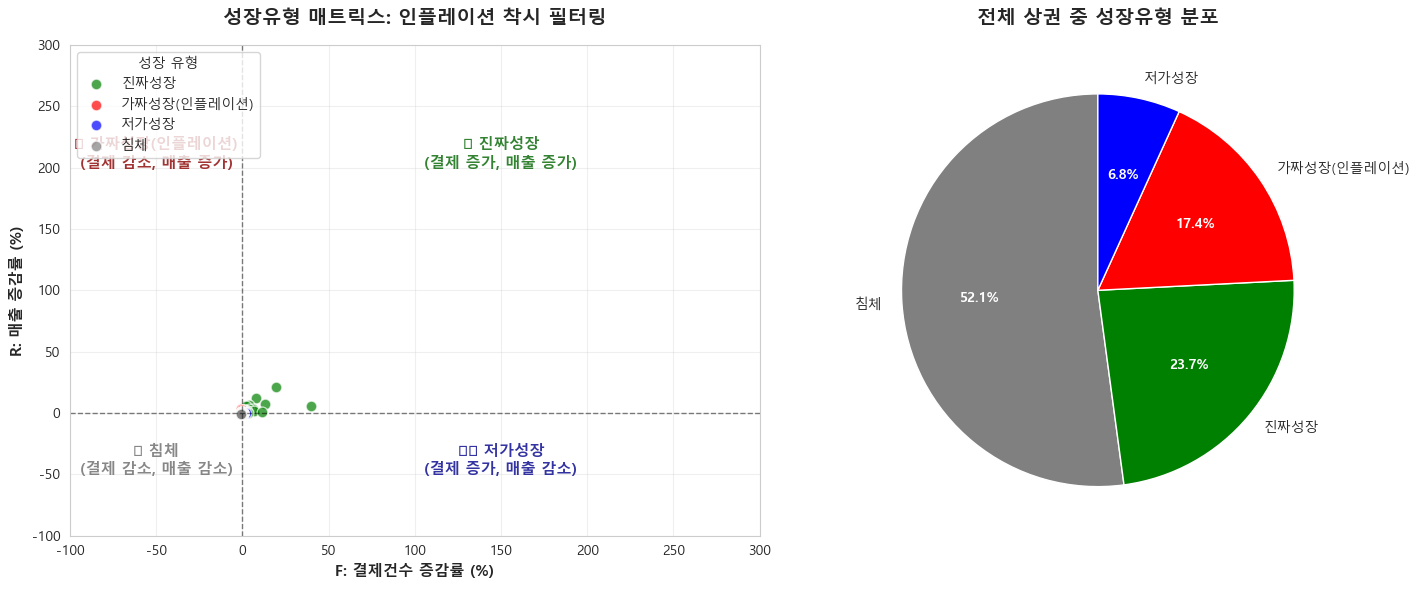


✅ 인플레이션 필터링 분석 및 시각화 완료


In [164]:
# %% 성장유형 시각화 고도화
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. 2D 산점도: 매출증감률 vs 결제건수증감률
# 'N/A' 라벨을 '일반'으로 대체 처리할 수 있도록 딕셔너리 확장
colors = {'진짜성장': 'green', '가짜성장(인플레이션)': 'red', '저가성장': 'blue', '침체': 'gray', '일반': 'black', 'N/A': 'black'}

for 유형 in rfm_clean['성장유형'].unique():
    mask = rfm_clean['성장유형'] == 유형
    ax1.scatter(rfm_clean[mask]['결제건수_증감률'], rfm_clean[mask]['R_매출증감률'], 
                label=유형, alpha=0.7, color=colors.get(유형, 'black'), s=60, edgecolor='white')

# 사분면 분할 기준선 (0% 성장 기준)
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# 🎯 직관적 라벨 텍스트 추가 (4개의 사분면에 각각 텍스트 배치)
ax1.text(150, 200, '🚀 진짜성장\n(결제 증가, 매출 증가)', fontsize=11, ha='center', color='darkgreen', fontweight='bold', alpha=0.8)
ax1.text(-50, 200, '🚨 가짜성장(인플레이션)\n(결제 감소, 매출 증가)', fontsize=11, ha='center', color='darkred', fontweight='bold', alpha=0.8)
ax1.text(-50, -50, '📉 침체\n(결제 감소, 매출 감소)', fontsize=11, ha='center', color='dimgray', fontweight='bold', alpha=0.8)
ax1.text(150, -50, '🏷️ 저가성장\n(결제 증가, 매출 감소)', fontsize=11, ha='center', color='darkblue', fontweight='bold', alpha=0.8)

# 축 및 제목 설정
ax1.set_xlabel('F: 결제건수 증감률 (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('R: 매출 증감률 (%)', fontsize=11, fontweight='bold')
ax1.set_title('성장유형 매트릭스: 인플레이션 착시 필터링', fontsize=14, fontweight='bold', pad=15)

# 아웃라이어 절삭 (데이터가 잘 퍼져 보이도록 돋보기 효과)
ax1.set_xlim(-100, 300) 
ax1.set_ylim(-100, 300)

ax1.legend(title='성장 유형', fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. 파이 차트
# 성장분류 데이터 파이 차트 생성 (색상을 산점도와 통일)
wedges, texts, autotexts = ax2.pie(성장분류.values, labels=성장분류.index, autopct='%1.1f%%', 
                                   startangle=90, colors=[colors.get(x, 'black') for x in 성장분류.index])

# 파이 차트 내부 퍼센트 글씨 가독성 향상
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax2.set_title('전체 상권 중 성장유형 분포', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print('\n✅ 인플레이션 필터링 분석 및 시각화 완료')

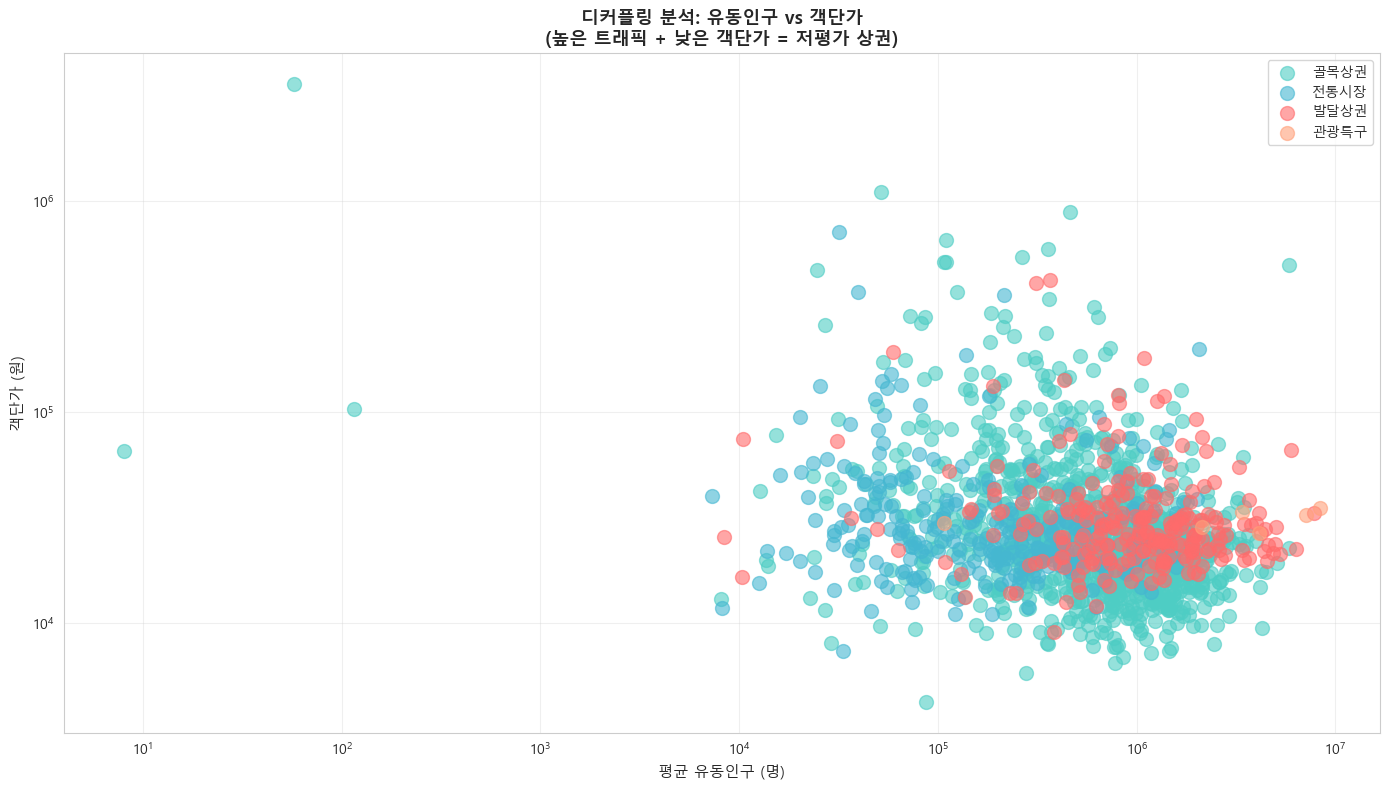


유동인구 vs 객단가 상관계수: -0.084
→ 약한 상관 = "트래픽 많지만 객단가 낮은" 상권이 존재함 (디커플링 확인)


In [165]:
# %% 디커플링 분석: 유동인구(트래픽) vs 객단가(구매력)
fig, ax = plt.subplots(figsize=(14, 8))

상권유형들 = rfm_clean['상권_구분_코드_명'].unique()
색상맵 = {'발달상권': '#FF6B6B', '골목상권': '#4ECDC4', '전통시장': '#45B7D1', '관광특구': '#FFA07A'}

for 상권유형 in 상권유형들:
    if pd.isna(상권유형):
        continue
    mask = rfm_clean['상권_구분_코드_명'] == 상권유형
    ax.scatter(rfm_clean[mask]['평균_유동인구'], rfm_clean[mask]['M_객단가'], 
              label=상권유형, alpha=0.6, s=100, color=색상맵.get(상권유형, 'gray'))

ax.set_xlabel('평균 유동인구 (명)', fontsize=11)
ax.set_ylabel('객단가 (원)', fontsize=11)
ax.set_title('디커플링 분석: 유동인구 vs 객단가\n(높은 트래픽 + 낮은 객단가 = 저평가 상권)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 로그 스케일 (극단치로 인한 압축 방지)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '디커플링분석.png', dpi=100, bbox_inches='tight')
plt.show()

# 상관계수
corr = rfm_clean['평균_유동인구'].corr(rfm_clean['M_객단가'])
print(f'\n유동인구 vs 객단가 상관계수: {corr:.3f}')
if abs(corr) < 0.3:
    print('→ 약한 상관 = "트래픽 많지만 객단가 낮은" 상권이 존재함 (디커플링 확인)')
else:
    print('→ 강한 상관 = 트래픽과 객단가가 함께 움직임')

In [166]:
# %% 저평가 가치주 상권 탐지 (개선)
# 조건: F점수(결제건수) 높음 + M점수(객단가) 낮음 = 고객 많지만 저객단가 상권

rfm_clean['상권분류'] = '일반_상권'  # 기본값을 N/A에서 일반_상권으로 변경

# 명확한 분류 우선순위
# 1. 스타_상권 (그대로 유지)
rfm_clean.loc[(rfm_clean['R_점수'] >= 4) & (rfm_clean['F_점수'] >= 4) & (rfm_clean['M_점수'] >= 3), '상권분류'] = '스타_상권'

# 2. 위험_상권 (그대로 유지: 전체 지표 최하위)
rfm_clean.loc[(rfm_clean['R_점수'] <= 2) & (rfm_clean['F_점수'] <= 2) & (rfm_clean['M_점수'] <= 2), '상권분류'] = '위험_상권'

# 3. 고평가_버블 (수정: F는 높으나 M이 낮은 '트래픽 함정' 상권)
rfm_clean.loc[(rfm_clean['F_점수'] >= 4) & (rfm_clean['M_점수'] <= 2), '상권분류'] = '고평가_버블'

# 4. 저평가_가치주 (수정: F는 낮으나 M이 높은 '알짜배기' 상권)
rfm_clean.loc[(rfm_clean['F_점수'] <= 2) & (rfm_clean['M_점수'] >= 4), '상권분류'] = '저평가_가치주'

print('=== 상권 분류 (RFM 기반) ===\n')
분류결과 = rfm_clean['상권분류'].value_counts()
print(분류결과)

# 저평가 가치주 상위 10
print('\n【 저평가 가치주 Top 10 】')
저평가 = rfm_clean[rfm_clean['상권분류'] == '저평가_가치주'].sort_values('F_결제건수', ascending=False).head(10)
if len(저평가) > 0:
    print(저평가[['상권_코드_명', '자치구_코드_명', '상권_구분_코드_명', 'F_결제건수', 'M_객단가', 'R_매출증감률']].to_string())
else:
    print('해당 상권 없음')

# 고평가 버블 상위 10
print('\n【 고평가 버블 Top 10 】')
고평가 = rfm_clean[rfm_clean['상권분류'] == '고평가_버블'].sort_values('M_객단가', ascending=False).head(10)
if len(고평가) > 0:
    print(고평가[['상권_코드_명', '자치구_코드_명', '상권_구분_코드_명', 'F_결제건수', 'M_객단가', 'R_매출증감률']].to_string())
else:
    print('해당 상권 없음')

# 스타 상권 상위 10
print('\n【 스타 상권 Top 10 】')
스타 = rfm_clean[rfm_clean['상권분류'] == '스타_상권'].sort_values('RFM_합계', ascending=False).head(10)
if len(스타) > 0:
    print(스타[['상권_코드_명', '자치구_코드_명', '상권_구분_코드_명', 'F_결제건수', 'M_객단가', 'R_매출증감률', 'RFM_합계']].to_string())
else:
    print('해당 상권 없음')

=== 상권 분류 (RFM 기반) ===

상권분류
일반_상권      677
저평가_가치주    371
고평가_버블     302
스타_상권      154
위험_상권       71
Name: count, dtype: int64

【 저평가 가치주 Top 10 】
                상권_코드_명 자치구_코드_명 상권_구분_코드_명    F_결제건수          M_객단가   R_매출증감률
821   방현초등학교(방배119안전센터)      서초구       골목상권  347706.0  201310.989865 -0.025473
897            대림1동주민센터     영등포구       골목상권  342267.5   31904.182224 -0.036919
1462       황학동주방가구거리상점가       중구       전통시장  339876.0   57691.849631 -0.234295
668      숭례문수입상가(남대문시장)       중구       전통시장  333602.0   49095.458288 -0.003447
1002            청계천공구상가       중구       전통시장  325148.5   50592.529123 -0.052300
325              행당역 2번      성동구       골목상권  323635.5   52305.494688  0.075687
855             국악고교사거리      강남구       골목상권  318298.0   48728.855489 -0.029649
423              석촌역 6번      송파구       골목상권  313352.5   38954.877287  0.044006
228               은평세무서      은평구       골목상권  311605.5   54020.725603  0.120515
949             오류동역 3번      구로구       골목상권  309651.0   3174

In [167]:
# %% 임대료 기준 상권 필터링
# 자치구별 월세 중앙값으로 진입 비용 부담이 낮은 상권 추출

임대료_기준 = 60  # 만원 (이 값을 바꿔서 기준 조정 가능)

df_임대료필터 = rfm_clean[rfm_clean['월세_임대료_중앙값'] <= 임대료_기준].copy()

n_전체 = len(rfm_clean)
n_필터 = len(df_임대료필터)
pct = n_필터 / n_전체 * 100
print('=== 월세', 임대료_기준, '만원 이하 상권 필터링 결과 ===')
print(f'전체 {n_전체}개 중 {n_필터}개 ({pct:.1f}%)')
print()

# 상권분류 분포
print('[ 상권분류 분포 ]')
print(df_임대료필터['상권분류'].value_counts())
print()

# 저평가 가치주 중 임대료 저렴한 곳 Top 10
print('[ 저평가 가치주 + 저임대료 Top 10 (결제건수 기준) ]')
mask = df_임대료필터['상권분류'] == '저평가_가치주'
df_추천 = df_임대료필터[mask].sort_values('F_결제건수', ascending=False).head(10)
cols = ['상권_코드_명', '자치구_코드_명', '월세_임대료_중앙값', 'F_결제건수', 'M_객단가', 'R_매출증감률', 'RFM_합계']
print(df_추천[cols].to_string(index=False))
print()

# 자치구별 통과 상권 수
print('[ 자치구별 필터 통과 상권 수 ]')
print(df_임대료필터.groupby('자치구_코드_명')['상권_코드'].count().sort_values(ascending=False).to_string())


=== 월세 60 만원 이하 상권 필터링 결과 ===
전체 1575개 중 1165개 (74.0%)

[ 상권분류 분포 ]
상권분류
일반_상권      511
저평가_가치주    250
고평가_버블     242
스타_상권      107
위험_상권       55
Name: count, dtype: int64

[ 저평가 가치주 + 저임대료 Top 10 (결제건수 기준) ]
          상권_코드_명 자치구_코드_명  월세_임대료_중앙값   F_결제건수        M_객단가   R_매출증감률  RFM_합계
         대림1동주민센터     영등포구        53.0 342267.5 31904.182224 -0.036919       9
           석촌역 6번      송파구        60.0 313352.5 38954.877287  0.044006      10
            은평세무서      은평구        50.0 311605.5 54020.725603  0.120515      12
          오류동역 3번      구로구        46.0 309651.0 31749.983580 -0.042936       8
          능동로골목시장      광진구        55.0 306696.0 33450.203300  0.063874      10
           구로초등학교      구로구        46.0 306622.5 41980.126559  0.056937      10
 수유중앙골목시장(수유중앙시장)      강북구        50.0 298368.5 29647.868687 -0.048889       8
           신묵초등학교      중랑구        45.0 292078.0 32147.405237  0.070164      10
        우리은행응암동지점      은평구        50.0 286697.5 33479.905196 -0.127622       7

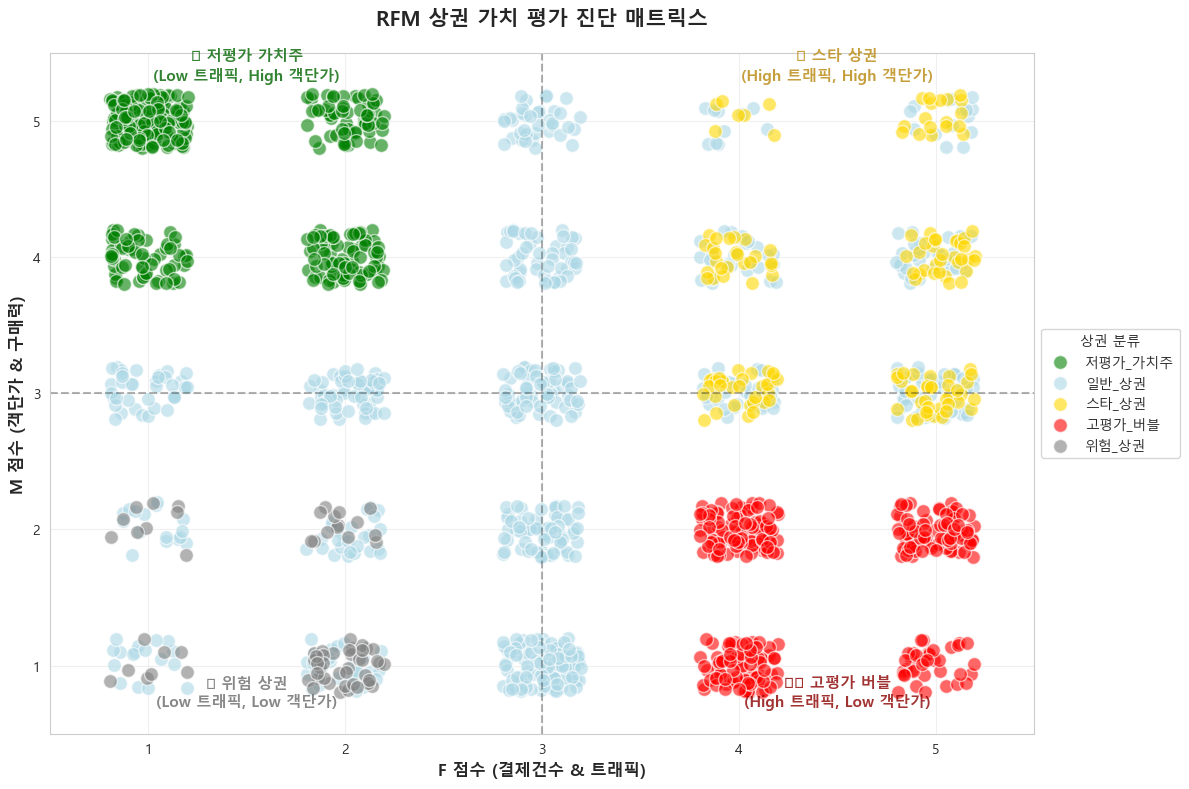


✅ F-M 매트릭스 고도화 분석 및 시각화 완료


In [168]:
# %% 상권분류 F-M 매트릭스 고도화
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# '일반_상권'이 반영된 색상 매핑
분류색상 = {'저평가_가치주': 'green', '고평가_버블': 'red', '스타_상권': 'gold', '위험_상권': 'gray', '일반_상권': 'lightblue'}

for 분류 in rfm_clean['상권분류'].unique():
    mask = rfm_clean['상권분류'] == 분류
    
    # 🎯 지터링(Jittering): 정수 데이터가 한 점에 겹치지 않도록 미세한 무작위 노이즈를 더함
    x_jitter = rfm_clean.loc[mask, 'F_점수'] + np.random.uniform(-0.2, 0.2, size=mask.sum())
    y_jitter = rfm_clean.loc[mask, 'M_점수'] + np.random.uniform(-0.2, 0.2, size=mask.sum())
    
    ax.scatter(x_jitter, y_jitter, 
               label=분류, alpha=0.6, s=100, color=분류색상.get(분류, 'gray'), edgecolor='white')

# 사분면 분할 십자선 (1~5점의 정중앙인 3.0 기준)
ax.axvline(x=3.0, color='black', linestyle='--', alpha=0.3)
ax.axhline(y=3.0, color='black', linestyle='--', alpha=0.3)

# 🎯 직관적 라벨 텍스트 추가 (배경에 사분면별 의미를 삽입)
ax.text(1.5, 5.3, '💎 저평가 가치주\n(Low 트래픽, High 객단가)', fontsize=11, ha='center', color='darkgreen', fontweight='bold', alpha=0.8)
ax.text(4.5, 5.3, '👑 스타 상권\n(High 트래픽, High 객단가)', fontsize=11, ha='center', color='darkgoldenrod', fontweight='bold', alpha=0.8)
ax.text(1.5, 0.7, '🚨 위험 상권\n(Low 트래픽, Low 객단가)', fontsize=11, ha='center', color='dimgray', fontweight='bold', alpha=0.8)
ax.text(4.5, 0.7, '⚠️ 고평가 버블\n(High 트래픽, Low 객단가)', fontsize=11, ha='center', color='darkred', fontweight='bold', alpha=0.8)

# 축 및 레이아웃 설정
ax.set_xlabel('F 점수 (결제건수 & 트래픽)', fontsize=12, fontweight='bold')
ax.set_ylabel('M 점수 (객단가 & 구매력)', fontsize=12, fontweight='bold')
ax.set_title('RFM 상권 가치 평가 진단 매트릭스', fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)

# 범례를 그래프 바깥으로 분리하여 가독성 확보
ax.legend(title='상권 분류', fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '상권분류_FM매트릭스_고도화.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ F-M 매트릭스 고도화 분석 및 시각화 완료')

In [169]:
# %% RFM 세그먼트별 특성 분석
print('=== RFM 세그먼트 프로파일 ===\n')

세그먼트 = rfm_clean.groupby('상권분류').agg({
    'R_매출증감률': ['mean', 'median'],
    'F_결제건수': ['mean', 'median'],
    'M_객단가': ['mean', 'median'],
    '결제전환율': 'mean',
    'RFM_합계': 'mean',
}).round(2)

print(세그먼트)

=== RFM 세그먼트 프로파일 ===

        R_매출증감률             F_결제건수                 M_객단가            결제전환율  \
           mean median        mean      median      mean    median   mean   
상권분류                                                                        
고평가_버블    -0.01  -0.02  3348921.02  1930040.75  17635.11  18535.64   6.34   
스타_상권      0.21   0.06  5530246.09  2946992.50  35181.48  29949.42  17.15   
위험_상권     -0.23  -0.16   171798.87   183033.00  14862.96  13976.30   1.05   
일반_상권      0.04  -0.03  1754529.25   595344.00  28735.51  24628.12   3.72   
저평가_가치주    0.96  -0.02    97320.93    67530.50  96758.55  49743.81  35.90   

        RFM_합계  
          mean  
상권분류            
고평가_버블    9.04  
스타_상권    12.67  
위험_상권     4.39  
일반_상권     8.63  
저평가_가치주   9.00  


In [170]:
# %% 분석 결과 저장 (최종 - 모든 정보 포함)
rfm_결과 = rfm_clean[['상권_코드', '상권_코드_명', '자치구_코드_명', '상권_구분_코드_명',
                    'R_매출증감률', 'F_결제건수', 'M_객단가', '결제전환율',
                    'R_점수', 'F_점수', 'M_점수', 'RFM_합계',
                    '성장유형', '상권분류', '진짜성장_플래그',
                    '주력_연령대', '10대_비중', '20대_비중', '30대_비중', '40대_비중', '50대_비중', '60대이상_비중',
                    '주력_성별', '남성_비중', '여성_비중',
                    '월세_임대료_중앙값', '월세_보증금_중앙값', '평균_면적',
                    '엑스좌표_값', '와이좌표_값']]

rfm_결과.to_csv(OUTPUT_DIR / 'RFM_최종분석결과.csv', index=False, encoding='utf-8-sig')

print(f'✅ 최종 RFM 분석 완료')
print(f'저장 파일: RFM_최종분석결과.csv')
print(f'데이터 크기: {rfm_결과.shape}')
print(f'\\n포함 정보:')
print(f'  - RFM 점수 및 분류')
print(f'  - 타겟층 (연령대, 성별)')
print(f'  - 월세 정보')
print(f'  - 성장 유형 분류')

rfm_결과.to_csv(OUTPUT_DIR / 'RFM_점수및분류.csv', index=False, encoding='utf-8-sig')

print(f'✅ RFM 분석 완료')
print(f'저장 위치: {OUTPUT_DIR / "RFM_점수및분류.csv"}')
print(f'데이터 크기: {rfm_결과.shape}')

✅ 최종 RFM 분석 완료
저장 파일: RFM_최종분석결과.csv
데이터 크기: (1575, 30)
\n포함 정보:
  - RFM 점수 및 분류
  - 타겟층 (연령대, 성별)
  - 월세 정보
  - 성장 유형 분류
✅ RFM 분석 완료
저장 위치: c:\sparta\project\03_final\seouldf\data\output\RFM_점수및분류.csv
데이터 크기: (1575, 30)


In [171]:
# %% 지도 시각화 (folium) - 좌표 변환
import folium
import pandas as pd
from pyproj import Transformer

# 🎯 핵심 수정: EPSG:5181 적용 및 always_xy=True 추가 (위경도 뒤집힘 완벽 방지)
transformer = Transformer.from_crs("EPSG:5181", "EPSG:4326", always_xy=True)

# 좌표 변환 적용
coords = []
for idx, row in rfm_결과.iterrows():
    if pd.notna(row['엑스좌표_값']) and pd.notna(row['와이좌표_값']):
        try:
            # always_xy=True 덕분에 결과가 무조건 (경도=lon, 위도=lat) 순서로 나옴
            lon, lat = transformer.transform(row['엑스좌표_값'], row['와이좌표_값'])
            # Folium은 [lat, lon] 순서를 요구하므로, 저장할 때 순서를 맞춰줌
            coords.append((lat, lon))
        except:
            coords.append((None, None))
    else:
        coords.append((None, None))

rfm_결과['lat'], rfm_결과['lon'] = zip(*coords)
rfm_결과_지도 = rfm_결과.dropna(subset=['lat', 'lon'])

print(f'지도 표시 가능 상권: {len(rfm_결과_지도)}개 / 전체 {len(rfm_결과)}개')
print('✅ 좌표 변환 완료')

지도 표시 가능 상권: 1575개 / 전체 1575개
✅ 좌표 변환 완료


In [172]:
# %% 1. RFM 합계 기반 지도 (주력 고객층 + 월세 정보 포함)
from IPython.display import display

seoul_center = [37.5665, 126.9780]
m = folium.Map(location=seoul_center, zoom_start=11, tiles='cartodbpositron')

# 색상 맵: RFM 합계 (3~15)
def get_color(rfm_score):
    if rfm_score <= 6:
        return 'red'
    elif rfm_score <= 9:
        return 'orange'
    elif rfm_score <= 12:
        return 'lightblue'
    else:
        return 'green'

for idx, row in rfm_결과_지도.iterrows():
    color = get_color(row['RFM_합계'])

    # null 안전 처리
    월세_str = f"{row['월세_임대료_중앙값']:,.0f}만원" if pd.notna(row['월세_임대료_중앙값']) else '정보없음'
    보증금_str = f"{row['월세_보증금_중앙값']:,.0f}만원" if pd.notna(row['월세_보증금_중앙값']) else '정보없음'
    연령대_str = str(row['주력_연령대']) if pd.notna(row['주력_연령대']) else '정보없음'
    성별_str = str(row['주력_성별']) if pd.notna(row['주력_성별']) else '정보없음'
    남성비중 = f"{row['남성_비중']:.0%}" if pd.notna(row['남성_비중']) else '-'
    여성비중 = f"{row['여성_비중']:.0%}" if pd.notna(row['여성_비중']) else '-'

    popup_html = f"""
    <div style="font-size:13px; min-width:260px;">
      <b style="font-size:14px;">{row['상권_코드_명']}</b><br>
      <span style="color:gray;">{row['자치구_코드_명']} · {row['상권_구분_코드_명']}</span><br>
      <hr style="margin:5px 0; border-color:#eee;">
      <b>RFM 점수</b><br>
      R: {row['R_점수']} | F: {row['F_점수']} | M: {row['M_점수']} → 합계: <b>{row['RFM_합계']}</b><br>
      분류: <b>{row['상권분류']}</b><br>
      매출증감률: {row['R_매출증감률']:.1%} | 객단가: {row['M_객단가']:,.0f}원<br>
      <hr style="margin:5px 0; border-color:#eee;">
      <b>주력 고객층</b><br>
      연령대: <b>{연령대_str}</b> | 성별: <b>{성별_str}</b><br>
      남성 {남성비중} / 여성 {여성비중}<br>
      <hr style="margin:5px 0; border-color:#eee;">
      <b>임대료 (자치구 중앙값, 2025년)</b><br>
      월세: <b>{월세_str}</b> | 보증금: {보증금_str}
    </div>
    """

    tooltip_text = f"{row['상권_코드_명']} | RFM {row['RFM_합계']}점 | 주요고객: {연령대_str} {성별_str} | 월세 {월세_str}"

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=folium.Tooltip(tooltip_text),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2
    ).add_to(m)

# 범례
legend_html_rfm = '''
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 260px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:13px; padding:12px; border-radius:5px;">
     <p style="margin:0; font-weight:bold; margin-bottom:8px;">RFM 합계 점수</p>
     <p style="margin:5px;"><span style="display:inline-block; width:15px; height:15px; background-color:red; border-radius:50%; margin-right:5px;"></span> 3~6점: 위험</p>
     <p style="margin:5px;"><span style="display:inline-block; width:15px; height:15px; background-color:orange; border-radius:50%; margin-right:5px;"></span> 7~9점: 평균</p>
     <p style="margin:5px;"><span style="display:inline-block; width:15px; height:15px; background-color:lightblue; border-radius:50%; margin-right:5px;"></span> 10~12점: 우수</p>
     <p style="margin:5px;"><span style="display:inline-block; width:15px; height:15px; background-color:green; border-radius:50%; margin-right:5px;"></span> 13~15점: 최고</p>
     <hr style="margin:8px 0; border-color:#eee;">
     <p style="margin:0; color:gray; font-size:11px;">● 마커 클릭 시: 주력 고객층(연령대·성별) 및<br>&nbsp;&nbsp;자치구 월세 정보 확인 가능</p>
     <p style="margin:2px 0; color:gray; font-size:11px;">● 마커 호버 시: 간략 정보 툴팁 표시</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html_rfm))

m.save(str(OUTPUT_DIR / '지도_RFM합계.html'))
print('✅ 지도 저장: 지도_RFM합계.html')

display(m)

✅ 지도 저장: 지도_RFM합계.html


In [173]:
# %% RFM 합계 지도 - 5중 인터랙티브 필터 (상권분류·상권유형·성장유형·자치구·월세)
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# ── 월세 구간 분류 함수 ──
def 월세구간(val):
    if pd.isna(val):   return '정보없음'
    if val <= 50:      return '50만원 이하'
    if val <= 65:      return '51~65만원'
    if val <= 80:      return '66~80만원'
    return '81만원 이상'

# ── 필터 옵션 ──
opt_분류   = ['전체'] + sorted(rfm_결과_지도['상권분류'].dropna().unique().tolist())
opt_유형   = ['전체'] + sorted(rfm_결과_지도['상권_구분_코드_명'].dropna().unique().tolist())
opt_성장   = ['전체'] + sorted(rfm_결과_지도['성장유형'].dropna().unique().tolist())
opt_자치구 = ['전체'] + sorted(rfm_결과_지도['자치구_코드_명'].dropna().unique().tolist())
opt_월세   = ['전체', '50만원 이하', '51~65만원', '66~80만원', '81만원 이상']

_style  = {'description_width': '70px'}
_layout = widgets.Layout(width='210px')

dd_분류   = widgets.Dropdown(options=opt_분류,   description='상권분류:', style=_style, layout=_layout)
dd_유형   = widgets.Dropdown(options=opt_유형,   description='상권유형:', style=_style, layout=_layout)
dd_성장   = widgets.Dropdown(options=opt_성장,   description='성장유형:', style=_style, layout=widgets.Layout(width='235px'))
dd_자치구 = widgets.Dropdown(options=opt_자치구, description='자치구:',   style=_style, layout=_layout)
dd_월세   = widgets.Dropdown(options=opt_월세,   description='월세구간:', style=_style, layout=_layout)

count_label = widgets.HTML()
map_output  = widgets.Output()

def get_color(score):
    if score <= 6:  return 'red'
    if score <= 9:  return 'orange'
    if score <= 12: return 'lightblue'
    return 'green'

def update_map(*args):
    df_f = rfm_결과_지도.copy()

    if dd_분류.value   != '전체': df_f = df_f[df_f['상권분류']         == dd_분류.value]
    if dd_유형.value   != '전체': df_f = df_f[df_f['상권_구분_코드_명'] == dd_유형.value]
    if dd_성장.value   != '전체': df_f = df_f[df_f['성장유형']          == dd_성장.value]
    if dd_자치구.value != '전체': df_f = df_f[df_f['자치구_코드_명']    == dd_자치구.value]
    if dd_월세.value   != '전체': df_f = df_f[df_f['월세_임대료_중앙값'].apply(월세구간) == dd_월세.value]

    count_label.value = f'<b style="color:#555;">표시 상권: {len(df_f)}개 / 전체 {len(rfm_결과_지도)}개</b>'

    with map_output:
        clear_output(wait=True)
        m_f = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

        for _, row in df_f.iterrows():
            color      = get_color(row['RFM_합계'])
            월세_str   = f"{row['월세_임대료_중앙값']:,.0f}만원"  if pd.notna(row['월세_임대료_중앙값'])  else '정보없음'
            보증금_str = f"{row['월세_보증금_중앙값']:,.0f}만원" if pd.notna(row['월세_보증금_중앙값']) else '정보없음'
            연령대_str = str(row['주력_연령대']) if pd.notna(row['주력_연령대']) else '정보없음'
            성별_str   = str(row['주력_성별'])   if pd.notna(row['주력_성별'])   else '정보없음'
            남성비중   = f"{row['남성_비중']:.0%}" if pd.notna(row['남성_비중']) else '-'
            여성비중   = f"{row['여성_비중']:.0%}" if pd.notna(row['여성_비중']) else '-'

            popup_html = (
                '<div style="font-size:13px; min-width:260px;">'
                f'<b style="font-size:14px;">{row["상권_코드_명"]}</b><br>'
                f'<span style="color:gray;">{row["자치구_코드_명"]} · {row["상권_구분_코드_명"]}</span><br>'
                '<hr style="margin:5px 0; border-color:#eee;">'
                '<b>RFM 점수</b><br>'
                f'R: {row["R_점수"]} | F: {row["F_점수"]} | M: {row["M_점수"]} → 합계: <b>{row["RFM_합계"]}</b><br>'
                f'분류: <b>{row["상권분류"]}</b> | 성장유형: {row["성장유형"]}<br>'
                f'매출증감률: {row["R_매출증감률"]:.1%} | 객단가: {row["M_객단가"]:,.0f}원<br>'
                '<hr style="margin:5px 0; border-color:#eee;">'
                '<b>주력 고객층</b><br>'
                f'연령대: <b>{연령대_str}</b> | 성별: <b>{성별_str}</b><br>'
                f'남성 {남성비중} / 여성 {여성비중}<br>'
                '<hr style="margin:5px 0; border-color:#eee;">'
                '<b>임대료 (자치구 중앙값, 2025년)</b><br>'
                f'월세: <b>{월세_str}</b> | 보증금: {보증금_str}'
                '</div>'
            )

            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=5,
                popup=folium.Popup(popup_html, max_width=320),
                tooltip=folium.Tooltip(
                    f"{row['상권_코드_명']} | RFM {row['RFM_합계']}점 | 주요고객: {연령대_str} {성별_str} | 월세 {월세_str}"
                ),
                color=color, fill=True, fillColor=color, fillOpacity=0.7, weight=2
            ).add_to(m_f)

        legend_html = '''
        <div style="position:fixed; bottom:50px; right:50px; width:260px;
             background:white; border:2px solid grey; z-index:9999;
             font-size:13px; padding:12px; border-radius:5px;">
          <p style="margin:0; font-weight:bold; margin-bottom:8px;">RFM 합계 점수</p>
          <p style="margin:5px;"><span style="display:inline-block;width:15px;height:15px;background:red;border-radius:50%;margin-right:5px;"></span>3~6점: 위험</p>
          <p style="margin:5px;"><span style="display:inline-block;width:15px;height:15px;background:orange;border-radius:50%;margin-right:5px;"></span>7~9점: 평균</p>
          <p style="margin:5px;"><span style="display:inline-block;width:15px;height:15px;background:lightblue;border-radius:50%;margin-right:5px;"></span>10~12점: 우수</p>
          <p style="margin:5px;"><span style="display:inline-block;width:15px;height:15px;background:green;border-radius:50%;margin-right:5px;"></span>13~15점: 최고</p>
          <hr style="margin:8px 0; border-color:#eee;">
          <p style="margin:0; color:gray; font-size:11px;">● 클릭: 상세 정보 팝업<br>● 호버: 간략 툴팁</p>
        </div>'''
        m_f.get_root().html.add_child(folium.Element(legend_html))
        display(m_f)

for dd in [dd_분류, dd_유형, dd_성장, dd_자치구, dd_월세]:
    dd.observe(update_map, names='value')

display(widgets.VBox([
    widgets.HTML('<h3>🗺️ RFM 합계 지도 — 인터랙티브 필터</h3>'),
    widgets.HBox([dd_분류, dd_유형, dd_성장]),
    widgets.HBox([dd_자치구, dd_월세]),
    count_label,
]))
display(map_output)
update_map()

Output()

In [174]:
# %% my_map.html - 필터 내장 독립 HTML 지도 (상권분류·상권유형·성장유형·자치구·월세)
import json as _json

records = []
for _, row in rfm_결과_지도.iterrows():
    records.append({
        'lat':     round(float(row['lat']), 6),
        'lon':     round(float(row['lon']), 6),
        'name':    str(row['상권_코드_명']),
        'gu':      str(row['자치구_코드_명']),
        'stype':   str(row['상권_구분_코드_명']),
        'cls':     str(row['상권분류']),
        'growth':  str(row['성장유형']),
        'rfm':     int(row['RFM_합계']),
        'r':       int(row['R_점수']),
        'f':       int(row['F_점수']),
        'm':       int(row['M_점수']),
        'rchg':    round(float(row['R_매출증감률']) * 100, 1),
        'price':   int(row['M_객단가']),
        'age':     str(row['주력_연령대'])   if pd.notna(row['주력_연령대'])   else '',
        'gender':  str(row['주력_성별'])     if pd.notna(row['주력_성별'])     else '',
        'male':    round(float(row['남성_비중']) * 100, 1) if pd.notna(row['남성_비중']) else 0,
        'female':  round(float(row['여성_비중']) * 100, 1) if pd.notna(row['여성_비중']) else 0,
        'rent':    float(row['월세_임대료_중앙값'])  if pd.notna(row['월세_임대료_중앙값'])  else 0,
        'deposit': float(row['월세_보증금_중앙값']) if pd.notna(row['월세_보증금_중앙값']) else 0,
    })

data_js = _json.dumps(records, ensure_ascii=False)
total   = len(records)

def _opts(vals):
    return '\n'.join(f'<option value="{v}">{v}</option>' for v in vals)

all_cls    = sorted(rfm_결과_지도['상권분류'].dropna().unique())
all_stype  = sorted(rfm_결과_지도['상권_구분_코드_명'].dropna().unique())
all_growth = sorted(rfm_결과_지도['성장유형'].dropna().unique())
all_gu     = sorted(rfm_결과_지도['자치구_코드_명'].dropna().unique())

html = f"""
<!DOCTYPE html>
<html lang='ko'>
<head>
  <meta charset='utf-8'>
  <title>RFM 상권 분석 지도</title>
  <link rel='stylesheet' href='https://unpkg.com/leaflet@1.9.4/dist/leaflet.css'/>
  <script src='https://unpkg.com/leaflet@1.9.4/dist/leaflet.js'></script>
  <style>
    * {{ margin:0; padding:0; box-sizing:border-box; }}
    body {{ font-family:'Malgun Gothic',sans-serif; }}
    #panel {{
      position:fixed; top:10px; left:50%; transform:translateX(-50%);
      z-index:9999; background:white; border:2px solid #aaa;
      border-radius:8px; padding:10px 16px;
      box-shadow:0 2px 8px rgba(0,0,0,.2);
      display:flex; align-items:flex-end; gap:12px; flex-wrap:wrap;
    }}
    #panel label {{ font-size:11px; color:#777; display:block; margin-bottom:3px; }}
    #panel select {{ font-size:13px; padding:4px 6px; border:1px solid #ccc; border-radius:4px; cursor:pointer; }}
    #badge {{ font-size:12px; color:#333; background:#f0f0f0; padding:4px 10px; border-radius:4px; white-space:nowrap; }}
    #map {{ height:100vh; width:100%; }}
    #legend {{
      position:fixed; bottom:30px; right:20px; background:white;
      border:2px solid #aaa; border-radius:6px; padding:10px 14px;
      font-size:13px; z-index:9999; box-shadow:0 2px 6px rgba(0,0,0,.15);
    }}
    #legend p {{ margin:4px 0; display:flex; align-items:center; gap:6px; }}
    .dot {{ width:13px; height:13px; border-radius:50%; display:inline-block; flex-shrink:0; }}
  </style>
</head>
<body>
  <div id='panel'>
    <div><label>상권분류</label>
      <select id='fc'><option value=''>전체</option>{_opts(all_cls)}</select></div>
    <div><label>상권유형</label>
      <select id='fs'><option value=''>전체</option>{_opts(all_stype)}</select></div>
    <div><label>성장유형</label>
      <select id='fg'><option value=''>전체</option>{_opts(all_growth)}</select></div>
    <div><label>자치구</label>
      <select id='fu'><option value=''>전체</option>{_opts(all_gu)}</select></div>
    <div><label>월세구간</label>
      <select id='fr'>
        <option value=''>전체</option>
        <option>50만원 이하</option>
        <option>51~65만원</option>
        <option>66~80만원</option>
        <option>81만원 이상</option>
      </select></div>
    <div id='badge'>전체 {total}개</div>
  </div>

  <div id='map'></div>

  <div id='legend'>
    <b style='display:block;margin-bottom:6px;'>RFM 합계 점수</b>
    <p><span class='dot' style='background:red'></span>3~6점: 위험</p>
    <p><span class='dot' style='background:orange'></span>7~9점: 평균</p>
    <p><span class='dot' style='background:#87CEEB'></span>10~12점: 우수</p>
    <p><span class='dot' style='background:green'></span>13~15점: 최고</p>
    <hr style='margin:7px 0;border-color:#eee;'>
    <p style='font-size:11px;color:gray;display:block;'>● 클릭: 상세 팝업 &nbsp; ● 호버: 툴팁</p>
  </div>

  <script>
  const DATA = {data_js};
  const TOTAL = {total};

  const map = L.map('map').setView([37.5665,126.9780],11);
  L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png',{{
    attribution:'© OpenStreetMap © CARTO', maxZoom:19
  }}).addTo(map);

  function getColor(rfm){{
    if(rfm<=6)  return 'red';
    if(rfm<=9)  return 'orange';
    if(rfm<=12) return '#87CEEB';
    return 'green';
  }}
  function rentBucket(r){{
    if(!r) return '정보없음';
    if(r<=50) return '50만원 이하';
    if(r<=65) return '51~65만원';
    if(r<=80) return '66~80만원';
    return '81만원 이상';
  }}
  function fmt(n){{ return n?n.toLocaleString()+'만원':'정보없음'; }}

  const markers = DATA.map(d => {{
    const c = getColor(d.rfm);
    const popup =
      '<div style="font-size:13px;min-width:250px;">'
      +'<b style="font-size:14px;">'+d.name+'</b><br>'
      +'<span style="color:gray;">'+d.gu+' · '+d.stype+'</span>'
      +'<hr style="margin:5px 0;border-color:#eee;">'
      +'<b>RFM 점수</b><br>'
      +'R:'+d.r+' | F:'+d.f+' | M:'+d.m+' → 합계: <b>'+d.rfm+'</b><br>'
      +'분류: <b>'+d.cls+'</b> | 성장유형: '+d.growth+'<br>'
      +'매출증감률: '+d.rchg+'% | 객단가: '+d.price.toLocaleString()+'원'
      +'<hr style="margin:5px 0;border-color:#eee;">'
      +'<b>주력 고객층</b><br>'
      +'연령대: <b>'+d.age+'</b> | 성별: <b>'+d.gender+'</b><br>'
      +'남성 '+(d.male||'-')+'% / 여성 '+(d.female||'-')+'%'
      +'<hr style="margin:5px 0;border-color:#eee;">'
      +'<b>임대료 (자치구 중앙값, 2025년)</b><br>'
      +'월세: <b>'+fmt(d.rent)+'</b> | 보증금: '+fmt(d.deposit)
      +'</div>';
    const m = L.circleMarker([d.lat,d.lon],{{
      radius:5, color:c, fillColor:c, fillOpacity:0.7, weight:2
    }}).bindPopup(popup)
      .bindTooltip(d.name+' | RFM '+d.rfm+'점 | 주요고객: '+d.age+' '+d.gender+' | 월세 '+fmt(d.rent));
    m._d = d;
    return m;
  }});

  const group = L.layerGroup(markers).addTo(map);

  function applyFilter(){{
    const fc = document.getElementById('fc').value;
    const fs = document.getElementById('fs').value;
    const fg = document.getElementById('fg').value;
    const fu = document.getElementById('fu').value;
    const fr = document.getElementById('fr').value;
    group.clearLayers();
    let n = 0;
    markers.forEach(m => {{
      const d = m._d;
      if(fc && d.cls    !== fc) return;
      if(fs && d.stype  !== fs) return;
      if(fg && d.growth !== fg) return;
      if(fu && d.gu     !== fu) return;
      if(fr && rentBucket(d.rent) !== fr) return;
      group.addLayer(m); n++;
    }});
    document.getElementById('badge').textContent = '표시: '+n+'개 / 전체 '+TOTAL+'개';
  }}

  ['fc','fs','fg','fu','fr'].forEach(id =>
    document.getElementById(id).addEventListener('change', applyFilter)
  );
  </script>
</body></html>
"""

out = OUTPUT_DIR / 'my_map.html'
out.write_text(html, encoding='utf-8')
print(f'저장 완료: {out}')
print(f'상권 수: {total}개')

저장 완료: c:\sparta\project\03_final\seouldf\data\output\my_map.html
상권 수: 1575개


In [175]:
# %% 2. 상권분류 기반 지도 (저평가/고평가/스타/위험/일반)
# tiles 옵션을 'cartodbpositron' 으로 변경합니다.
m2 = folium.Map(location=seoul_center, zoom_start=11, tiles='cartodbpositron')

분류색상 = {
    '저평가_가치주': 'green',
    '고평가_버블': 'red',
    '스타_상권': 'gold',
    '위험_상권': 'gray',
    '일반_상권': 'lightblue'
}

for idx, row in rfm_결과_지도.iterrows():
    color = 분류색상.get(row['상권분류'], 'lightblue')
    popup_text = f"""
    <b>{row['상권_코드_명']}</b><br>
    분류: <span style="color:{color}; font-weight:bold;">{row['상권분류']}</span><br>
    자치구: {row['자치구_코드_명']}<br>
    상권유형: {row['상권_구분_코드_명']}<br>
    성장유형: {row['성장유형']}<br>
    매출증감률: {row['R_매출증감률']:.1%}<br>
    결제건수: {row['F_결제건수']:,.0f}<br>
    객단가: {row['M_객단가']:,.0f}원
    """
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        popup = folium.Popup(popup_text, max_width=300, parse_html=False),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.8,
        weight=2
    ).add_to(m2)

# 범례 추가
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 220px; height: 240px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding:10px; border-radius:5px;">
     <p style="margin:0; font-weight:bold; margin-bottom:10px;">상권 분류</p>
     <p style="margin:5px;"><i class="fa fa-circle" style="color:green"></i> 저평가 가치주</p>
     <p style="margin:5px;"><i class="fa fa-circle" style="color:red"></i> 고평가 버블</p>
     <p style="margin:5px;"><i class="fa fa-circle" style="color:gold"></i> 스타 상권</p>
     <p style="margin:5px;"><i class="fa fa-circle" style="color:gray"></i> 위험 상권</p>
     <p style="margin:5px;"><i class="fa fa-circle" style="color:lightblue"></i> 일반 상권</p>
</div>
'''
m2.get_root().html.add_child(folium.Element(legend_html))

m2.save(str(OUTPUT_DIR / '지도_상권분류.html'))
print('✅ 지도 저장: 지도_상권분류.html')
print(f'\n지도 폴더: {OUTPUT_DIR}')

from IPython.display import display

# m 이라고만 쓰지 말고, display(m) 함수를 사용합니다.
display(m)

✅ 지도 저장: 지도_상권분류.html

지도 폴더: c:\sparta\project\03_final\seouldf\data\output


In [176]:
# %% 인터랙티브 필터링: 상권유형/분류별 상세 분석
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# 필터 옵션 정의
상권유형_옵션 = ['전체'] + sorted(rfm_clean['상권_구분_코드_명'].dropna().unique().tolist())
상권분류_옵션 = ['전체'] + sorted(rfm_clean['상권분류'].unique().tolist())
성장유형_옵션 = ['전체'] + sorted(rfm_clean['성장유형'].unique().tolist())
자치구_옵션 = ['전체'] + sorted(rfm_clean['자치구_코드_명'].unique().tolist())

# 드롭다운 위젯 생성
상권유형_dropdown = widgets.Dropdown(options=상권유형_옵션, description='상권유형:')
상권분류_dropdown = widgets.Dropdown(options=상권분류_옵션, description='상권분류:')
성장유형_dropdown = widgets.Dropdown(options=성장유형_옵션, description='성장유형:')
자치구_dropdown = widgets.Dropdown(options=자치구_옵션, description='자치구:')

# 출력 영역
output = widgets.Output()

def update_analysis(상권유형_val, 상권분류_val, 성장유형_val, 자치구_val):
    """필터에 따라 분석을 업데이트"""
    with output:
        clear_output(wait=True)
        
        # 필터링
        filtered_df = rfm_clean.copy()
        
        if 상권유형_val != '전체':
            filtered_df = filtered_df[filtered_df['상권_구분_코드_명'] == 상권유형_val]
        if 상권분류_val != '전체':
            filtered_df = filtered_df[filtered_df['상권분류'] == 상권분류_val]
        if 성장유형_val != '전체':
            filtered_df = filtered_df[filtered_df['성장유형'] == 성장유형_val]
        if 자치구_val != '전체':
            filtered_df = filtered_df[filtered_df['자치구_코드_명'] == 자치구_val]
        
        print(f'🔍 필터링 결과: {len(filtered_df)}개 상권')
        print(f'(전체 1,575개 중 {len(filtered_df)/1575*100:.1f}%)\n')
        
        if len(filtered_df) == 0:
            print('⚠️ 해당하는 상권이 없습니다.')
            return
        
        # 통계 정보
        print('=' * 70)
        print('📊 필터링된 상권의 RFM 통계\n')
        stats = filtered_df[['R_매출증감률', 'F_결제건수', 'M_객단가', 'RFM_합계']].describe().round(2)
        print(stats)
        
        print('\n' + '=' * 70)
        print('🏆 분류별 분포\n')
        분류분포 = filtered_df['상권분류'].value_counts()
        for 분류, 개수 in 분류분포.items():
            비중 = 개수 / len(filtered_df) * 100
            print(f'  {분류}: {개수}개 ({비중:.1f}%)')
        
        print('\n' + '=' * 70)
        print('📈 성장유형 분포\n')
        성장분포 = filtered_df['성장유형'].value_counts()
        for 유형, 개수 in 성장분포.items():
            비중 = 개수 / len(filtered_df) * 100
            print(f'  {유형}: {개수}개 ({비중:.1f}%)')
        
        print('\n' + '=' * 70)
        print('🌟 Top 5 상권 (RFM 합계 기준)\n')
        top5 = filtered_df.nlargest(5, 'RFM_합계')[
            ['상권_코드_명', '자치구_코드_명', 'RFM_합계', 'R_점수', 'F_점수', 'M_점수', '상권분류']
        ]
        print(top5.to_string(index=False))
        
        print('\n' + '=' * 70)
        print('👥 주요 타겟층\n')
        연령대_분포 = filtered_df[[col for col in filtered_df.columns if '비중' in col and any(age in col for age in ['10대', '20대', '30대', '40대', '50대', '60대'])]].mean() * 100
        성별_분포 = filtered_df[['남성_비중', '여성_비중']].mean() * 100
        
        print('연령대별 비중:')
        for col in sorted(연령대_분포.index):
            age_label = col.replace('_비중', '')
            print(f'  {age_label}: {연령대_분포[col]:.1f}%')
        
        print('\n성별 비중:')
        print(f'  남성: {성별_분포["남성_비중"]:.1f}%')
        print(f'  여성: {성별_분포["여성_비중"]:.1f}%')
        
        # 월세 정보
        월세_평균 = filtered_df['월세_임대료_중앙값'].mean()
        보증금_평균 = filtered_df['월세_보증금_중앙값'].mean()
        면적_평균 = filtered_df['평균_면적'].mean()
        
        if pd.notna(월세_평균):
            print('\n' + '=' * 70)
            print('🏠 임대료 정보 (2025년 중앙값)\n')
            print(f'  월세 임대료: {월세_평균:,.0f}만원')
            print(f'  보증금: {보증금_평균:,.0f}만원')
            print(f'  평균 면적: {면적_평균:.1f}m²')

# 상호작용 업데이트 함수 (변경이 있을 때마다 실행)
def on_change(change):
    update_analysis(
        상권유형_dropdown.value,
        상권분류_dropdown.value,
        성장유형_dropdown.value,
        자치구_dropdown.value
    )

# 이벤트 리스너 연결
상권유형_dropdown.observe(on_change, names='value')
상권분류_dropdown.observe(on_change, names='value')
성장유형_dropdown.observe(on_change, names='value')
자치구_dropdown.observe(on_change, names='value')

# UI 레이아웃 생성
filter_box = widgets.VBox([
    widgets.HTML('<h3>🔍 인터랙티브 필터링</h3>'),
    widgets.HBox([상권유형_dropdown, 상권분류_dropdown]),
    widgets.HBox([성장유형_dropdown, 자치구_dropdown]),
    widgets.HTML('<p style="color:gray; font-size:12px;">필터를 변경하면 실시간으로 분석이 업데이트됩니다</p>')
])

display(filter_box)
display(output)

# 초기 실행
update_analysis(
    상권유형_dropdown.value,
    상권분류_dropdown.value,
    성장유형_dropdown.value,
    자치구_dropdown.value
)

Output()